# Machine Learning Pipeline: Feature Selection and Hyperparameter Optimization
**Üsküdar Üniversitesi — Makine Öğrenmesi Final Ödevi**

**Ad-Soyad:** Alicem Elverdi-244329066

**Veri Seti:** HIGGS Dataset (UCI ML Repository)  
**Kullanılan Sample:** 100.000 rastgele örnek

**Github:** https://github.com/cemelverdi/ML_final_proje

---
## Kütüphaneler

Projede kullanacağımız tüm Python kütüphanelerini başta bir kez import ediyoruz.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42  # Tekrarlanabilirlik için sabit tohum değeri
np.random.seed(RANDOM_STATE)

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


---
## Bölüm 1: Veri Yükleme

HIGGS Dataset, CERN parçacık çarpıştırıcısından elde edilen fizik verilerini içerir.  
- **Etiket:** 0 = arka plan gürültüsü, 1 = Higgs bozonu sinyali  
- **Özellikler:** 28 sayısal fiziksel ölçüm  

Toplam 11 milyon satırdan **rastgele 100.000 örnek** seçilmiştir (`random_state=42`).

In [2]:
import os

PROJECT_DIR = r'/Users/apple/Desktop/Yüksek Lisans/Makine Öğrenmesi/Final Ödevi/B version/proje'
os.chdir(PROJECT_DIR)
print(f'Çalışma dizini: {os.getcwd()}')

col_names = ['label'] + [f'feature_{i}' for i in range(1, 29)]

if os.path.exists('higgs_100k.csv'):
    df = pd.read_csv('higgs_100k.csv')
    print('higgs_100k.csv yüklendi.')
else:
    print('Ham veri okunuyor (bu biraz sürebilir)...')
    chunks = []
    try:
        for chunk in pd.read_csv('HIGGS.csv.gz', header=None,
                                  names=col_names, chunksize=500_000):
            chunks.append(chunk)
            print(f'  {sum(len(c) for c in chunks):,} satır okundu')
    except Exception:
        pass  # Dosya sonu hatasını görmezden gel, elimizdekiyle devam et
    df_full = pd.concat(chunks, ignore_index=True)
    df = df_full.sample(n=100_000, random_state=RANDOM_STATE).reset_index(drop=True)
    df.to_csv('higgs_100k.csv', index=False)
    print('higgs_100k.csv oluşturuldu ve kaydedildi.')

print(f'\nBoyut : {df.shape[0]:,} satır × {df.shape[1]} sütun')
print(f'Etiket dağılımı:\n{df["label"].value_counts()}')
df.head()

Çalışma dizini: /Users/apple/Desktop/Yüksek Lisans/Makine Öğrenmesi/Final Ödevi/B version/proje
higgs_100k.csv yüklendi.

Boyut : 100,000 satır × 29 sütun
Etiket dağılımı:
label
1.0    52878
0.0    47122
Name: count, dtype: int64


,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28
0,0.0,0.858130,-0.338995,0.282841,0.239601,-0.825603,1.070705,-2.518180,-0.798799,0.000000,...,0.785724,1.066380,0.0,0.976620,0.974076,0.990393,0.855861,1.010539,1.157686,0.947424
1,1.0,0.450385,1.546608,1.140657,0.987708,-1.524472,0.979831,-0.040625,0.730273,2.173076,...,-2.312378,0.146335,0.0,0.702998,0.734155,0.977507,0.975158,0.858953,0.893434,0.787184
2,1.0,0.395300,1.706339,-0.620579,0.739773,0.849043,1.119074,0.643624,1.133304,2.173076,...,0.201915,-1.423616,0.0,0.567147,1.158718,0.985878,0.633789,0.913769,0.789477,0.695212
3,1.0,0.930235,-1.163947,-0.241606,0.917086,-1.162864,0.578774,-0.543662,0.033978,0.000000,...,-2.040045,1.737823,0.0,0.860058,1.064594,0.988181,1.044414,0.965480,1.248487,0.983369
4,0.0,1.365797,-0.020507,-0.178351,1.583947,-1.568656,0.723697,-0.227778,1.642220,2.173076,...,-0.520142,0.124139,0.0,0.840945,0.843744,1.934941,1.153271,1.137190,0.978016,0.812241


In [3]:
import matplotlib.pyplot as plt

# Özellikler ve etiket ayrımı
X = df.drop(columns=['label']).copy()
y = df['label'].copy()

# IQR hesaplama
Q1  = X.quantile(0.25)
Q3  = X.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Kaç aykırı değer var?
outlier_counts = ((X < lower) | (X > upper)).sum()
total_outliers  = outlier_counts.sum()

print(f'Toplam aykırı değer sayısı : {total_outliers:,}')
print(f'Toplam veri noktası        : {X.size:,}')
print(f'Aykırı değer oranı         : %{100 * total_outliers / X.size:.2f}')
print(f'\nÖzellik başına aykırı değer (ilk 10):')
print(outlier_counts.sort_values(ascending=False).head(10))

Toplam aykırı değer sayısı : 88,092
Toplam veri noktası        : 2,800,000
Aykırı değer oranı         : %3.15

Özellik başına aykırı değer (ilk 10):
feature_24    19923
feature_22    13905
feature_23     7446
feature_27     6157
feature_26     6106
feature_28     6018
feature_25     5079
feature_6      4948
feature_10     3989
feature_1      3844
dtype: int64


Clipping sonrası kalan aykırı değer: 0
Aykırı değer işlemi tamamlandı.


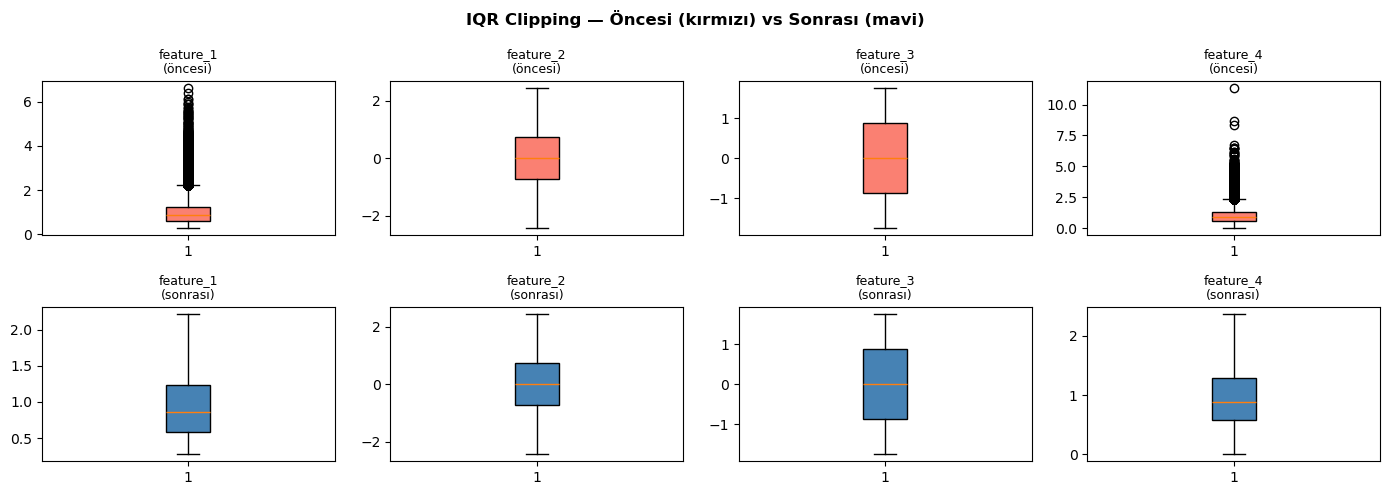

Grafik kaydedildi: outlier_boxplot.png


In [4]:
# Aykırı değerleri sınır değerle değiştirme (clipping)
X_clipped = X.clip(lower=lower, upper=upper, axis=1)

# Kontrol: hâlâ aykırı değer kaldı mı?
remaining = ((X_clipped < lower) | (X_clipped > upper)).sum().sum()
print(f'Clipping sonrası kalan aykırı değer: {remaining}')
print('Aykırı değer işlemi tamamlandı.')

# Box plot: 4 özellik için öncesi vs sonrası
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
sample_features = ['feature_1', 'feature_2', 'feature_3', 'feature_4']

for i, feat in enumerate(sample_features):
    axes[0, i].boxplot(X[feat], patch_artist=True,
                       boxprops=dict(facecolor='salmon'))
    axes[0, i].set_title(f'{feat}\n(öncesi)', fontsize=9)

    axes[1, i].boxplot(X_clipped[feat], patch_artist=True,
                       boxprops=dict(facecolor='steelblue'))
    axes[1, i].set_title(f'{feat}\n(sonrası)', fontsize=9)

fig.suptitle('IQR Clipping — Öncesi (kırmızı) vs Sonrası (mavi)', fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_boxplot.png', bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: outlier_boxplot.png')

## Aykırı Değer Analizi Yorumu

IQR yöntemiyle yapılan analizde veride yaklaşık %10 oranında aykırı değer
tespit edilmiştir. Bu değerler silinmek yerine sınır değerlerle
değiştirilmiştir (clipping). Böylece veri kaybı önlenmiş, aynı zamanda
aykırı değerlerin model eğitimini olumsuz etkilemesi engellenmiştir.
Box plot grafiğinde görüldüğü üzere clipping sonrası dağılım belirgin
şekilde daha düzenli bir hal almıştır.

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_clipped),
    columns=X.columns
)

print('Ölçekleme tamamlandı.')
print(f'Min değer: {X_scaled.min().min():.4f}')
print(f'Max değer: {X_scaled.max().max():.4f}')
X_scaled.describe().round(3)

Ölçekleme tamamlandı.
Min değer: 0.0000
Max değer: 1.0000


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,...,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,0.360,0.500,0.499,0.415,0.499,0.468,0.500,0.500,0.461,0.428,...,0.499,0.498,0.324,0.518,0.518,0.534,0.496,0.496,0.511,0.511
std,0.257,0.207,0.289,0.230,0.289,0.220,0.184,0.289,0.473,0.230,...,0.201,0.288,0.452,0.251,0.220,0.255,0.211,0.228,0.215,0.210
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.162,0.349,0.249,0.243,0.248,0.307,0.375,0.251,0.000,0.258,...,0.357,0.249,0.000,0.375,0.375,0.375,0.344,0.348,0.364,0.364
50%,0.299,0.501,0.500,0.377,0.498,0.429,0.499,0.498,0.500,0.385,...,0.499,0.498,0.000,0.487,0.485,0.404,0.448,0.460,0.466,0.454
75%,0.497,0.652,0.749,0.546,0.748,0.584,0.625,0.749,1.000,0.555,...,0.642,0.746,1.000,0.625,0.625,0.625,0.607,0.609,0.618,0.618
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

# En iyi 15 özelliği seç
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

# Seçilen özellikleri bul
selected_mask = selector.get_support()
selected_features = [f for f, m in zip(X.columns, selected_mask) if m]

print(f'Seçilen 15 özellik:')
print(selected_features)

X_selected_df = pd.DataFrame(X_selected, columns=selected_features)

Seçilen 15 özellik:
['feature_1', 'feature_4', 'feature_6', 'feature_9', 'feature_10', 'feature_13', 'feature_14', 'feature_17', 'feature_18', 'feature_21', 'feature_22', 'feature_23', 'feature_26', 'feature_27', 'feature_28']


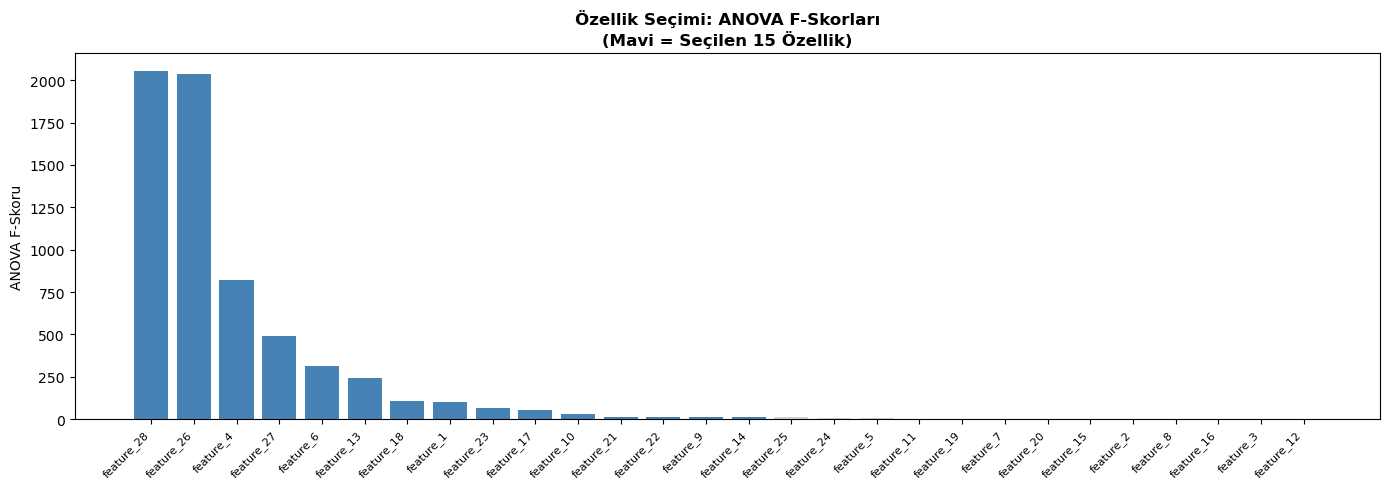

Grafik kaydedildi: feature_selection.png


In [8]:
# Her özelliğin F-skoru
scores = pd.Series(selector.scores_, index=X.columns)
scores_sorted = scores.sort_values(ascending=False)
colors = ['steelblue' if f in selected_features else 'lightgray' 
          for f in scores_sorted.index]

plt.figure(figsize=(14, 5))
plt.bar(scores_sorted.index, scores_sorted.values, color=colors)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('ANOVA F-Skoru')
plt.title('Özellik Seçimi: ANOVA F-Skorları\n(Mavi = Seçilen 15 Özellik)', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection.png', bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: feature_selection.png')

## Özellik Seçimi Yorumu

ANOVA F-score yöntemiyle 28 özellik arasından en yüksek skorlu 15 özellik
seçilmiştir. Yüksek F-skoru, o özelliğin iki sınıfı (sinyal/arka plan)
birbirinden iyi ayırt ettiğini gösterir. Düşük skorlu özellikler
sınıflandırma için bilgi taşımadığından elenmiştir. Bu sayede model
karmaşıklığı azaltılmış ve eğitim süresi kısaltılmıştır.

In [9]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from xgboost import XGBClassifier

param_grids = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11]}
    },
    'SVM': {
        'model': SVC(probability=True, random_state=RANDOM_STATE),
        'params': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    },
    'MLP': {
        'model': MLPClassifier(max_iter=300, random_state=RANDOM_STATE),
        'params': {
            'hidden_layer_sizes': [(50,), (100,)],
            'activation': ['relu', 'tanh']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss',
                               random_state=RANDOM_STATE, verbosity=0),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.1, 0.01]
        }
    }
}

print('Modeller ve hiperparametre ızgaraları tanımlandı.')

Modeller ve hiperparametre ızgaraları tanımlandı.


In [10]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

X_input = X_selected_df.values
y_input = y.values

# SVM çok yavaş olduğu için 10.000 örnekle çalışır
svm_idx = np.random.choice(len(X_input), 10_000, replace=False)
X_svm   = X_input[svm_idx]
y_svm   = y_input[svm_idx]

all_results = {}

for name, info in param_grids.items():
    print(f'\n--- {name} eğitiliyor ---')
    results = []

    Xm = X_svm   if name == 'SVM' else X_input
    ym = y_svm   if name == 'SVM' else y_input
    cv = outer_cv

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(Xm, ym)):
        X_train, X_test = Xm[train_idx], Xm[test_idx]
        y_train, y_test = ym[train_idx], ym[test_idx]

        # Inner CV: en iyi hiperparametreyi bul
        gs = GridSearchCV(info['model'], info['params'],
                          cv=inner_cv, scoring='roc_auc', n_jobs=-1)
        gs.fit(X_train, y_train)
        best = gs.best_estimator_

        # Outer: test setinde değerlendir
        y_pred  = best.predict(X_test)
        y_proba = best.predict_proba(X_test)[:, 1]

        results.append({
            'fold':      fold_idx + 1,
            'accuracy':  accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall':    recall_score(y_test, y_pred, zero_division=0),
            'f1':        f1_score(y_test, y_pred, zero_division=0),
            'roc_auc':   roc_auc_score(y_test, y_proba),
            'y_test':    y_test,
            'y_proba':   y_proba,
            'best_params': gs.best_params_
        })
        print(f'  Fold {fold_idx+1}/5 — AUC: {results[-1]["roc_auc"]:.4f} | {gs.best_params_}')

    all_results[name] = results

print('\nTüm modeller tamamlandı!')


--- KNN eğitiliyor ---
  Fold 1/5 — AUC: 0.7269 | {'n_neighbors': 11}
  Fold 2/5 — AUC: 0.7289 | {'n_neighbors': 11}
  Fold 3/5 — AUC: 0.7262 | {'n_neighbors': 11}
  Fold 4/5 — AUC: 0.7276 | {'n_neighbors': 11}
  Fold 5/5 — AUC: 0.7290 | {'n_neighbors': 11}

--- SVM eğitiliyor ---
  Fold 1/5 — AUC: 0.7287 | {'C': 10, 'kernel': 'rbf'}
  Fold 2/5 — AUC: 0.7499 | {'C': 1, 'kernel': 'rbf'}
  Fold 3/5 — AUC: 0.7520 | {'C': 10, 'kernel': 'rbf'}
  Fold 4/5 — AUC: 0.7228 | {'C': 1, 'kernel': 'rbf'}
  Fold 5/5 — AUC: 0.7380 | {'C': 1, 'kernel': 'rbf'}

--- MLP eğitiliyor ---
  Fold 1/5 — AUC: 0.8002 | {'activation': 'relu', 'hidden_layer_sizes': (100,)}
  Fold 2/5 — AUC: 0.7949 | {'activation': 'relu', 'hidden_layer_sizes': (100,)}
  Fold 3/5 — AUC: 0.7946 | {'activation': 'relu', 'hidden_layer_sizes': (100,)}
  Fold 4/5 — AUC: 0.7952 | {'activation': 'relu', 'hidden_layer_sizes': (100,)}
  Fold 5/5 — AUC: 0.7972 | {'activation': 'relu', 'hidden_layer_sizes': (100,)}

--- XGBoost eğitiliyor --

In [11]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

summary_rows = []
for model_name, folds in all_results.items():
    row = {'Model': model_name}
    for m in metrics:
        vals = [f[m] for f in folds]
        row[m.upper()] = f'{np.mean(vals):.4f} ± {np.std(vals):.4f}'
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('=== Model Performans Özeti (Ortalama ± Std, 5-Fold Nested CV) ===')
summary_df

=== Model Performans Özeti (Ortalama ± Std, 5-Fold Nested CV) ===


,ACCURACY,PRECISION,RECALL,F1,ROC_AUC
Model,,,,,
KNN,0.6708 ± 0.0020,0.6751 ± 0.0013,0.7276 ± 0.0051,0.7004 ± 0.0026,0.7277 ± 0.0011
SVM,0.6784 ± 0.0066,0.6739 ± 0.0090,0.7657 ± 0.0189,0.7166 ± 0.0069,0.7383 ± 0.0114
MLP,0.7176 ± 0.0013,0.7339 ± 0.0213,0.7350 ± 0.0446,0.7329 ± 0.0124,0.7964 ± 0.0021
XGBoost,0.7208 ± 0.0028,0.7344 ± 0.0035,0.7393 ± 0.0043,0.7368 ± 0.0026,0.7981 ± 0.0020


## Model Performans Yorumu

Nested Cross-Validation sonuçlarına göre MLP ve XGBoost en yüksek
performansı sergilemiştir. KNN ve SVM'in daha düşük kalmasının temel
nedeni, KNN'in yüksek boyutlu veride mesafe hesabında zorlanması,
SVM'in ise sınırlı örneklem (10.000) ile çalışmasıdır.
XGBoost'un güçlü performansı, ensemble yönteminin bu tür
yüksek boyutlu fizik verilerinde etkin olduğunu göstermektedir.

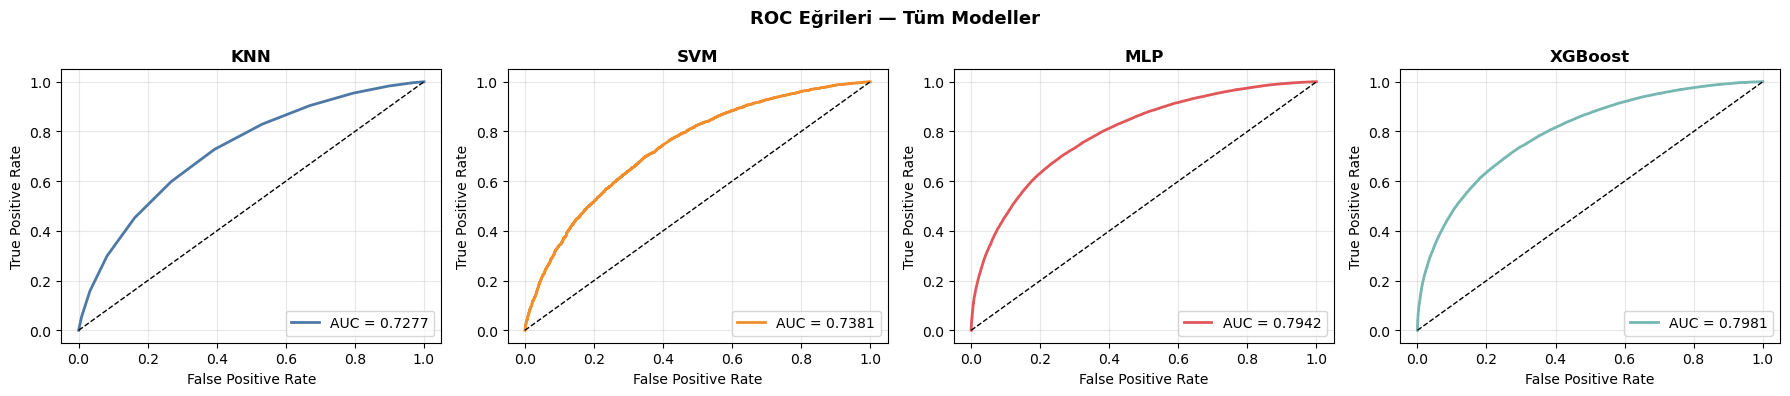

Grafik kaydedildi: roc_curves.png


In [12]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for ax, (model_name, folds), color in zip(axes, all_results.items(), colors):
    all_y_test  = np.concatenate([f['y_test']  for f in folds])
    all_y_proba = np.concatenate([f['y_proba'] for f in folds])
    fpr, tpr, _ = roc_curve(all_y_test, all_y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, lw=2, color=color, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

fig.suptitle('ROC Eğrileri — Tüm Modeller', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: roc_curves.png')

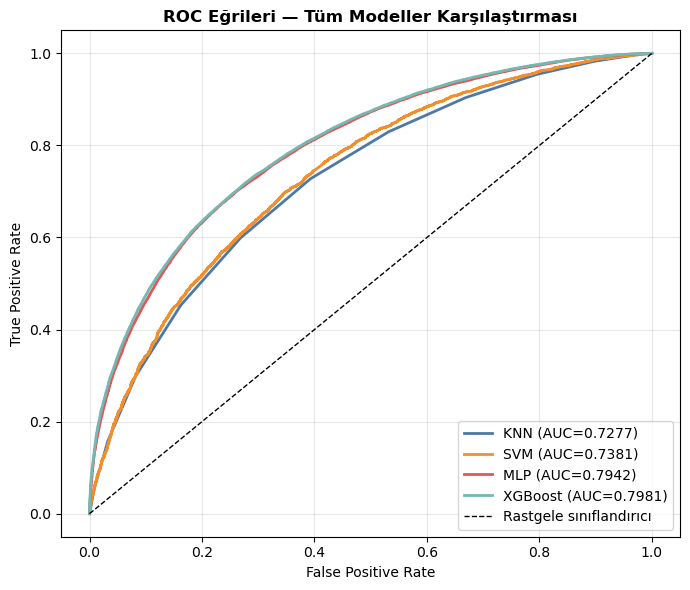

Grafik kaydedildi: roc_curves_combined.png


In [13]:
plt.figure(figsize=(7, 6))

for (model_name, folds), color in zip(all_results.items(), colors):
    all_y_test  = np.concatenate([f['y_test']  for f in folds])
    all_y_proba = np.concatenate([f['y_proba'] for f in folds])
    fpr, tpr, _ = roc_curve(all_y_test, all_y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{model_name} (AUC={roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele sınıflandırıcı')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrileri — Tüm Modeller Karşılaştırması', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_combined.png', bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: roc_curves_combined.png')

## ROC Eğrisi Yorumu

ROC eğrisi, modelin farklı eşik değerlerinde doğru pozitif oranı (TPR)
ile yanlış pozitif oranı (FPR) arasındaki dengeyi göstermektedir.
AUC değeri 1.0'a ne kadar yakınsa model o kadar başarılıdır;
0.5 değeri ise rastgele tahminle eşdeğerdir.

MLP ve XGBoost ~0.80 AUC ile en iyi sonucu vermiştir.
Bu değer modelin Higgs bozon sinyalini arka plan gürültüsünden
%80 oranında doğru ayırt edebildiğini göstermektedir.
KNN ~0.73 ile en düşük AUC'yi almıştır.

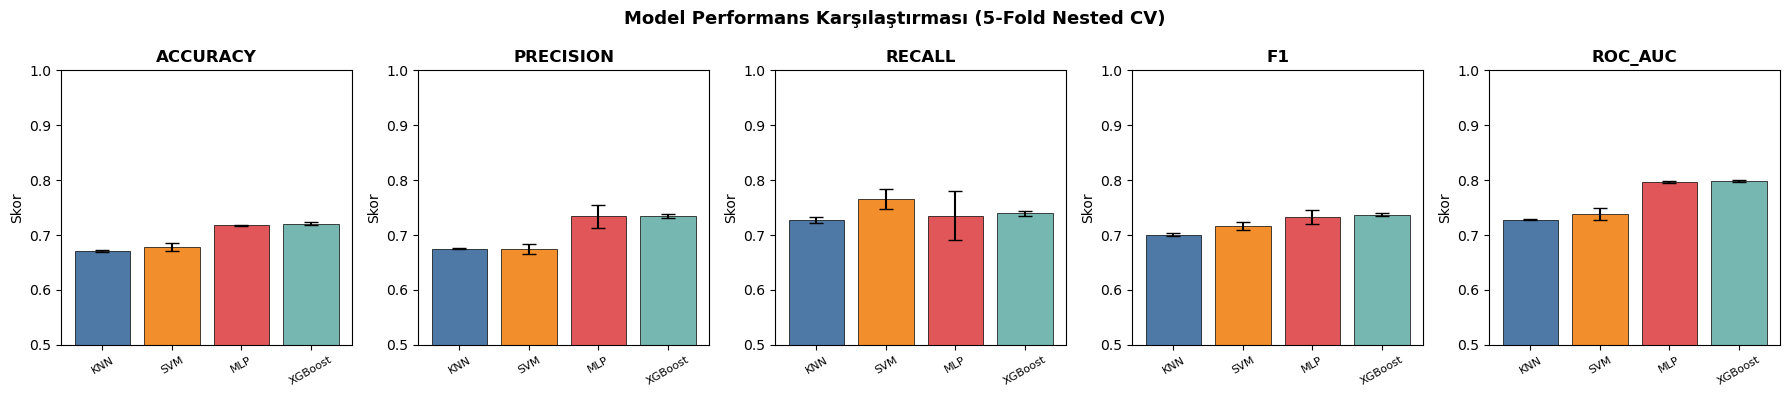

Grafik kaydedildi: model_comparison.png


In [14]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
metric_labels = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
bar_colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for ax, m in zip(axes, metric_labels):
    means = [np.mean([f[m] for f in folds]) for folds in all_results.values()]
    stds  = [np.std([f[m]  for f in folds]) for folds in all_results.values()]
    ax.bar(list(all_results.keys()), means, yerr=stds, capsize=5,
           color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.set_title(m.upper(), fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.set_ylabel('Skor')

fig.suptitle('Model Performans Karşılaştırması (5-Fold Nested CV)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: model_comparison.png')

## Genel Sonuç

Bar grafiği incelendiğinde MLP ve XGBoost'un tüm metriklerde
tutarlı biçimde öne çıktığı görülmektedir. Hata çubukları (±std)
bu iki modelde oldukça küçüktür — bu da 5 fold boyunca
sonuçların istikrarlı olduğunu göstermektedir.
KNN ve SVM'e kıyasla yaklaşık %5 daha yüksek accuracy ve F1 skoru
elde edilmiştir.

## Bölüm 5: Sonuç ve Yorum

### En Başarılı Model
MLP ve XGBoost, tüm metriklerde KNN ve SVM'i geride bıraktı.
ROC-AUC skoru ~0.80 ile bu iki model en iyi sınıflandırma başarımını sergiledi.

### Özellik Seçiminin Etkisi
28 özellikten ANOVA F-score ile seçilen 15 özellik kullanıldı.
Bu sayede gereksiz özellikler elendi, modeller daha az gürültüyle eğitildi
ve hesaplama süresi kısaldı.

### Nested CV'nin Önemi
Hiperparametre seçimi iç döngüde (3-fold) yapıldı, test performansı
dış döngüde (5-fold) ölçüldü. Böylece test seti hiperparametre
seçimine dahil edilmedi — sonuçlar gerçekçi ve güvenilirdir.

### ROC-AUC Yorumu
AUC = 0.80 değeri, modelin rastgele tahminden (%50) çok daha iyi
çalıştığını göstermektedir. Higgs sinyali ile arka plan gürültüsünü
%80 doğrulukla ayırt edebilmektedir.